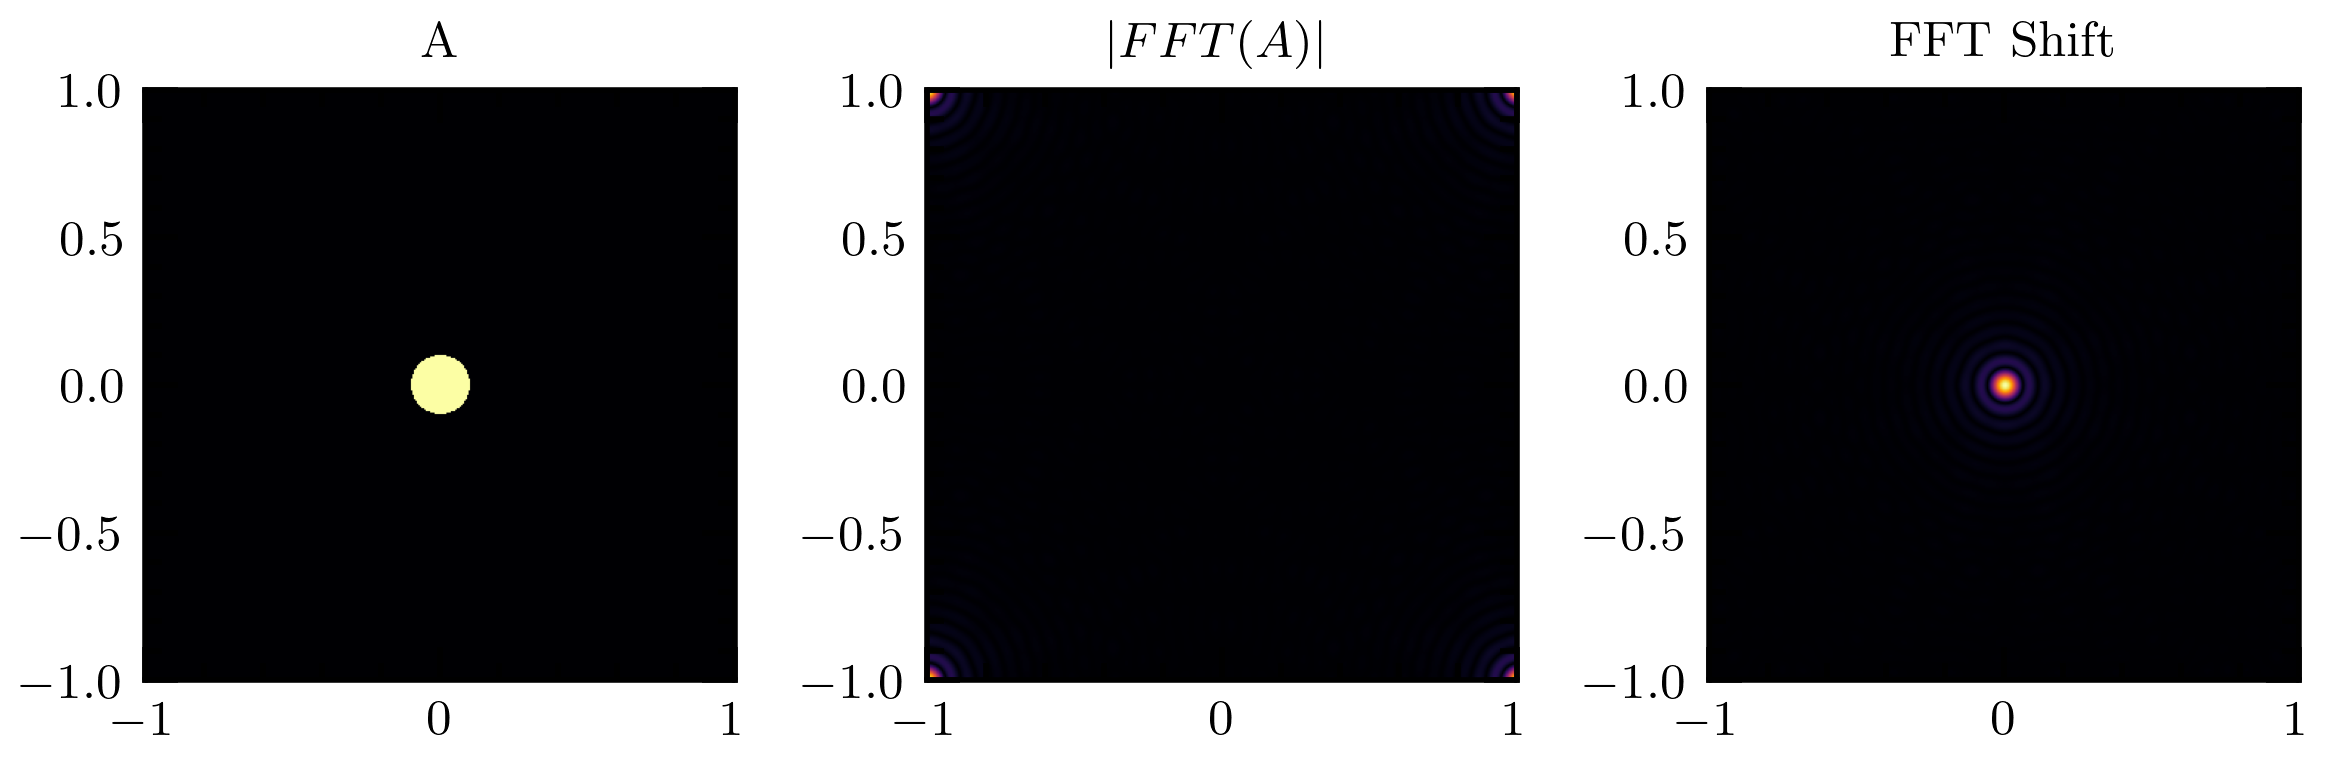

In [78]:
import numpy as np 
import matplotlib.pyplot as plt 
def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX- for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=9)
## boilerplate
x = np.linspace(-1,1,400)
y = np.linspace(-1,1,400)
xv, yv = np.meshgrid(x,y)

r = 0.1
A = (xv**2 + yv**2 <= r**2)

FA = np.abs(np.fft.fft2(A))
FAshft = np.fft.fftshift(FA)

## create horizontal subplots
fig, axs = plt.subplots(1, 3, figsize=(6, 2), dpi=400)

axs[0].imshow(A, extent=[-1,1,-1,1], cmap="inferno")
axs[0].set_title("A")
axs[0].grid()

axs[1].imshow(FA, extent=[-1,1,-1,1], cmap="inferno")
axs[1].set_title(r"$|FFT(A)|$")
axs[1].grid()

axs[2].imshow(FAshft, extent=[-1,1,-1,1], cmap="inferno")
axs[2].set_title("FFT Shift")
axs[2].grid()

plt.tight_layout()
plt.show()


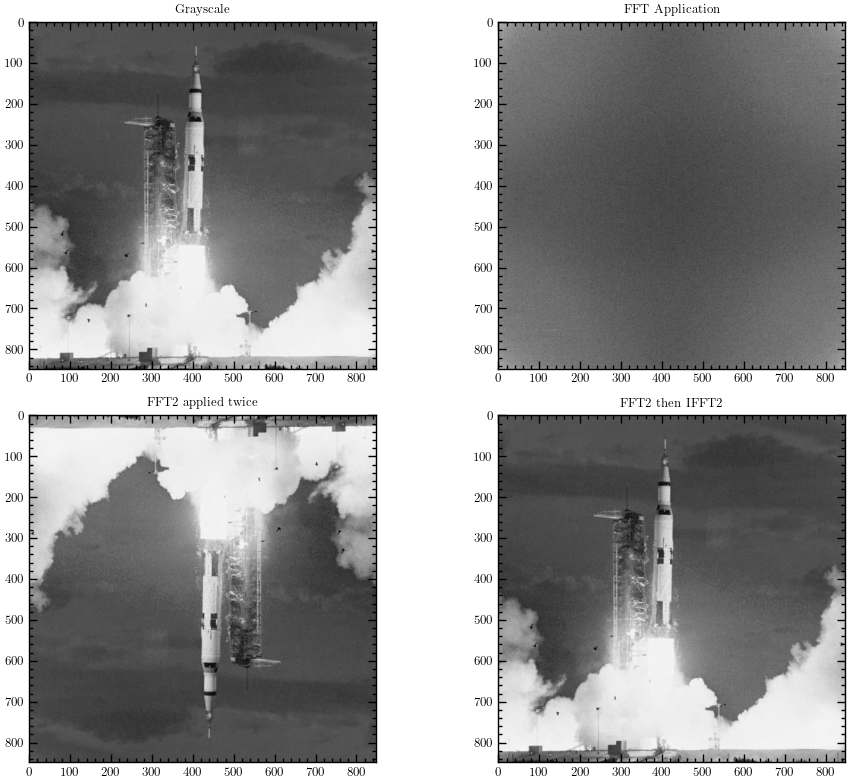

In [ ]:
import cv2
## Load image
img = cv2.imread("saturn.jpg")

## Crop a square portion (center crop)
h, w, _ = img.shape
size = min(h, w)
start_x = w // 2 - size // 2
start_y = h // 2 - size // 2
img_crop = img[start_y:start_y+size, start_x:start_x+size]

## Convert to grayscale
gray = cv2.cvtColor(img_crop, cv2.COLOR_BGR2GRAY)

## FFT twice
fft1 = np.fft.fft2(gray)
fft2 = np.fft.fft2(fft1)
recon_fft1 = np.abs(fft1)
recon_fft2 = np.abs(fft2)

## FFT followed by IFFT
fft_once = np.fft.fft2(gray)
ifft = np.fft.ifft2(fft_once)
recon_ifft = np.abs(ifft)

## Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0][0].set_title("Grayscale")
axs[0][0].imshow(gray, cmap='gray')
axs[0][0].grid()

axs[0][1].set_title("FFT Application")
axs[0][1].imshow(np.log(1+recon_fft1), cmap='gray')
axs[0][1].grid()

axs[1][0].set_title("FFT2 applied twice")
axs[1][0].imshow(recon_fft2, cmap='gray')
axs[1][0].grid()

axs[1][1].set_title("FFT2 then IFFT2")
axs[1][1].imshow(recon_ifft, cmap='gray')
axs[1][1].grid()


plt.tight_layout()
plt.show()

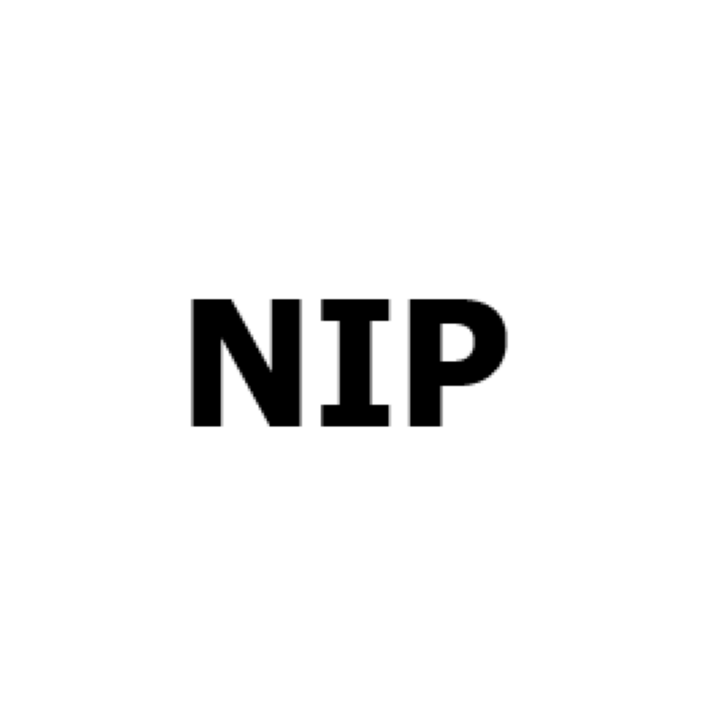

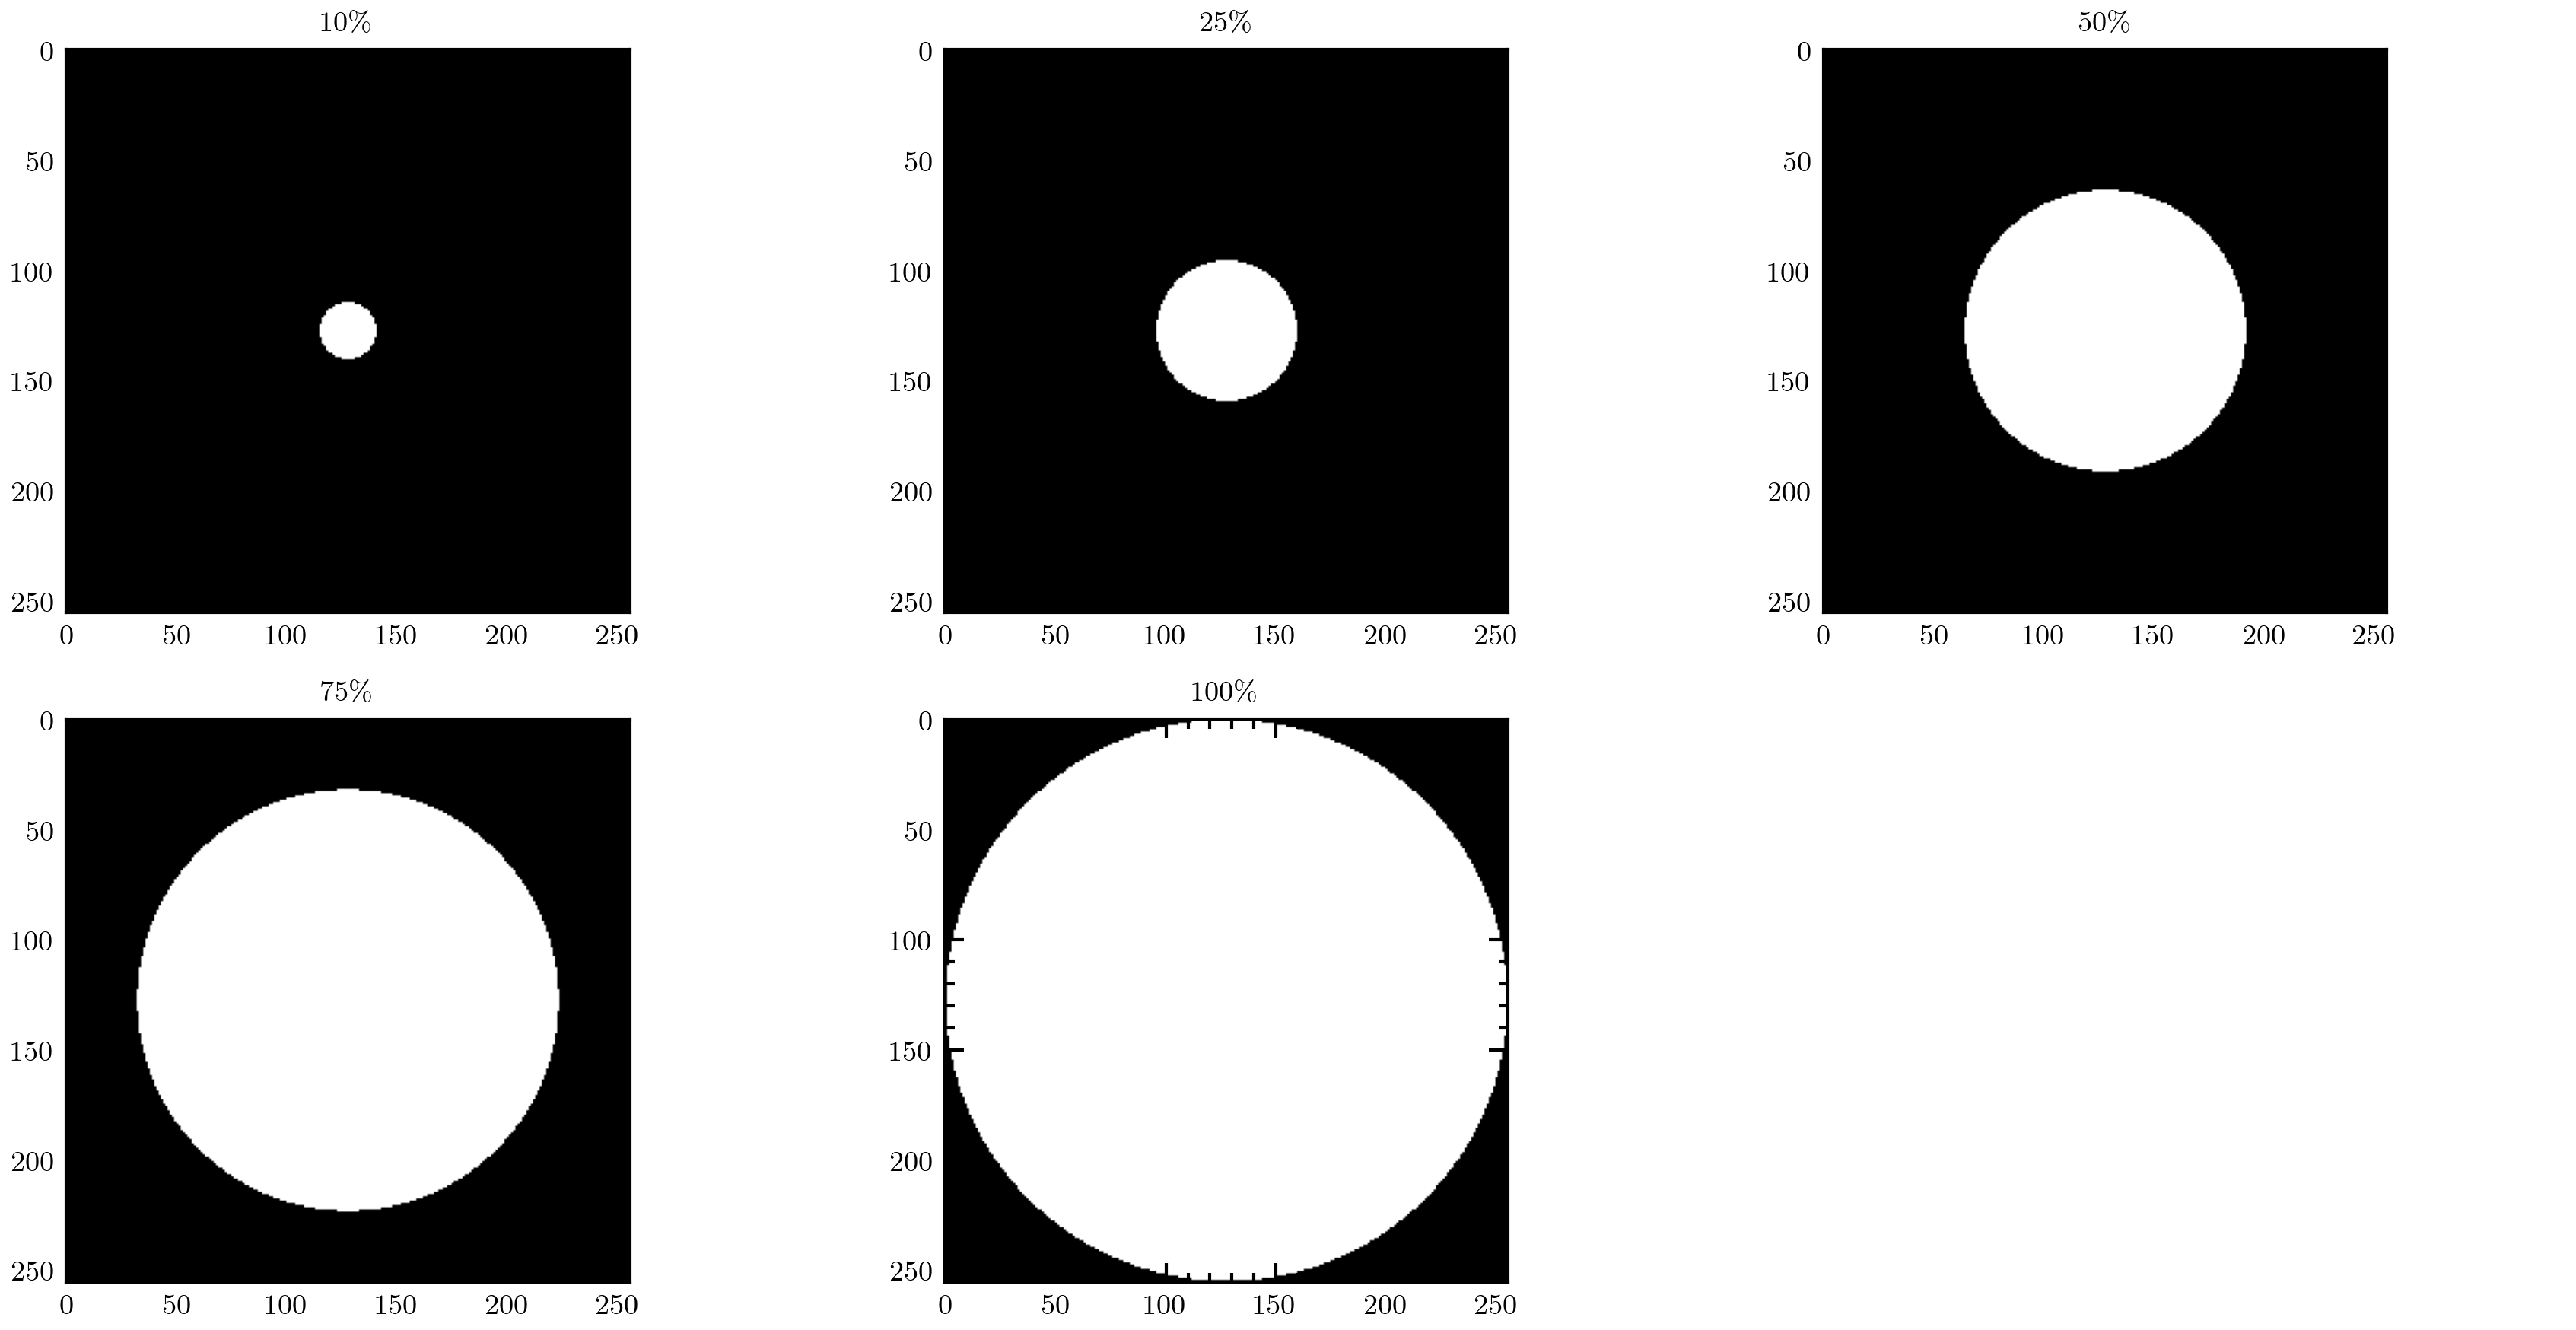

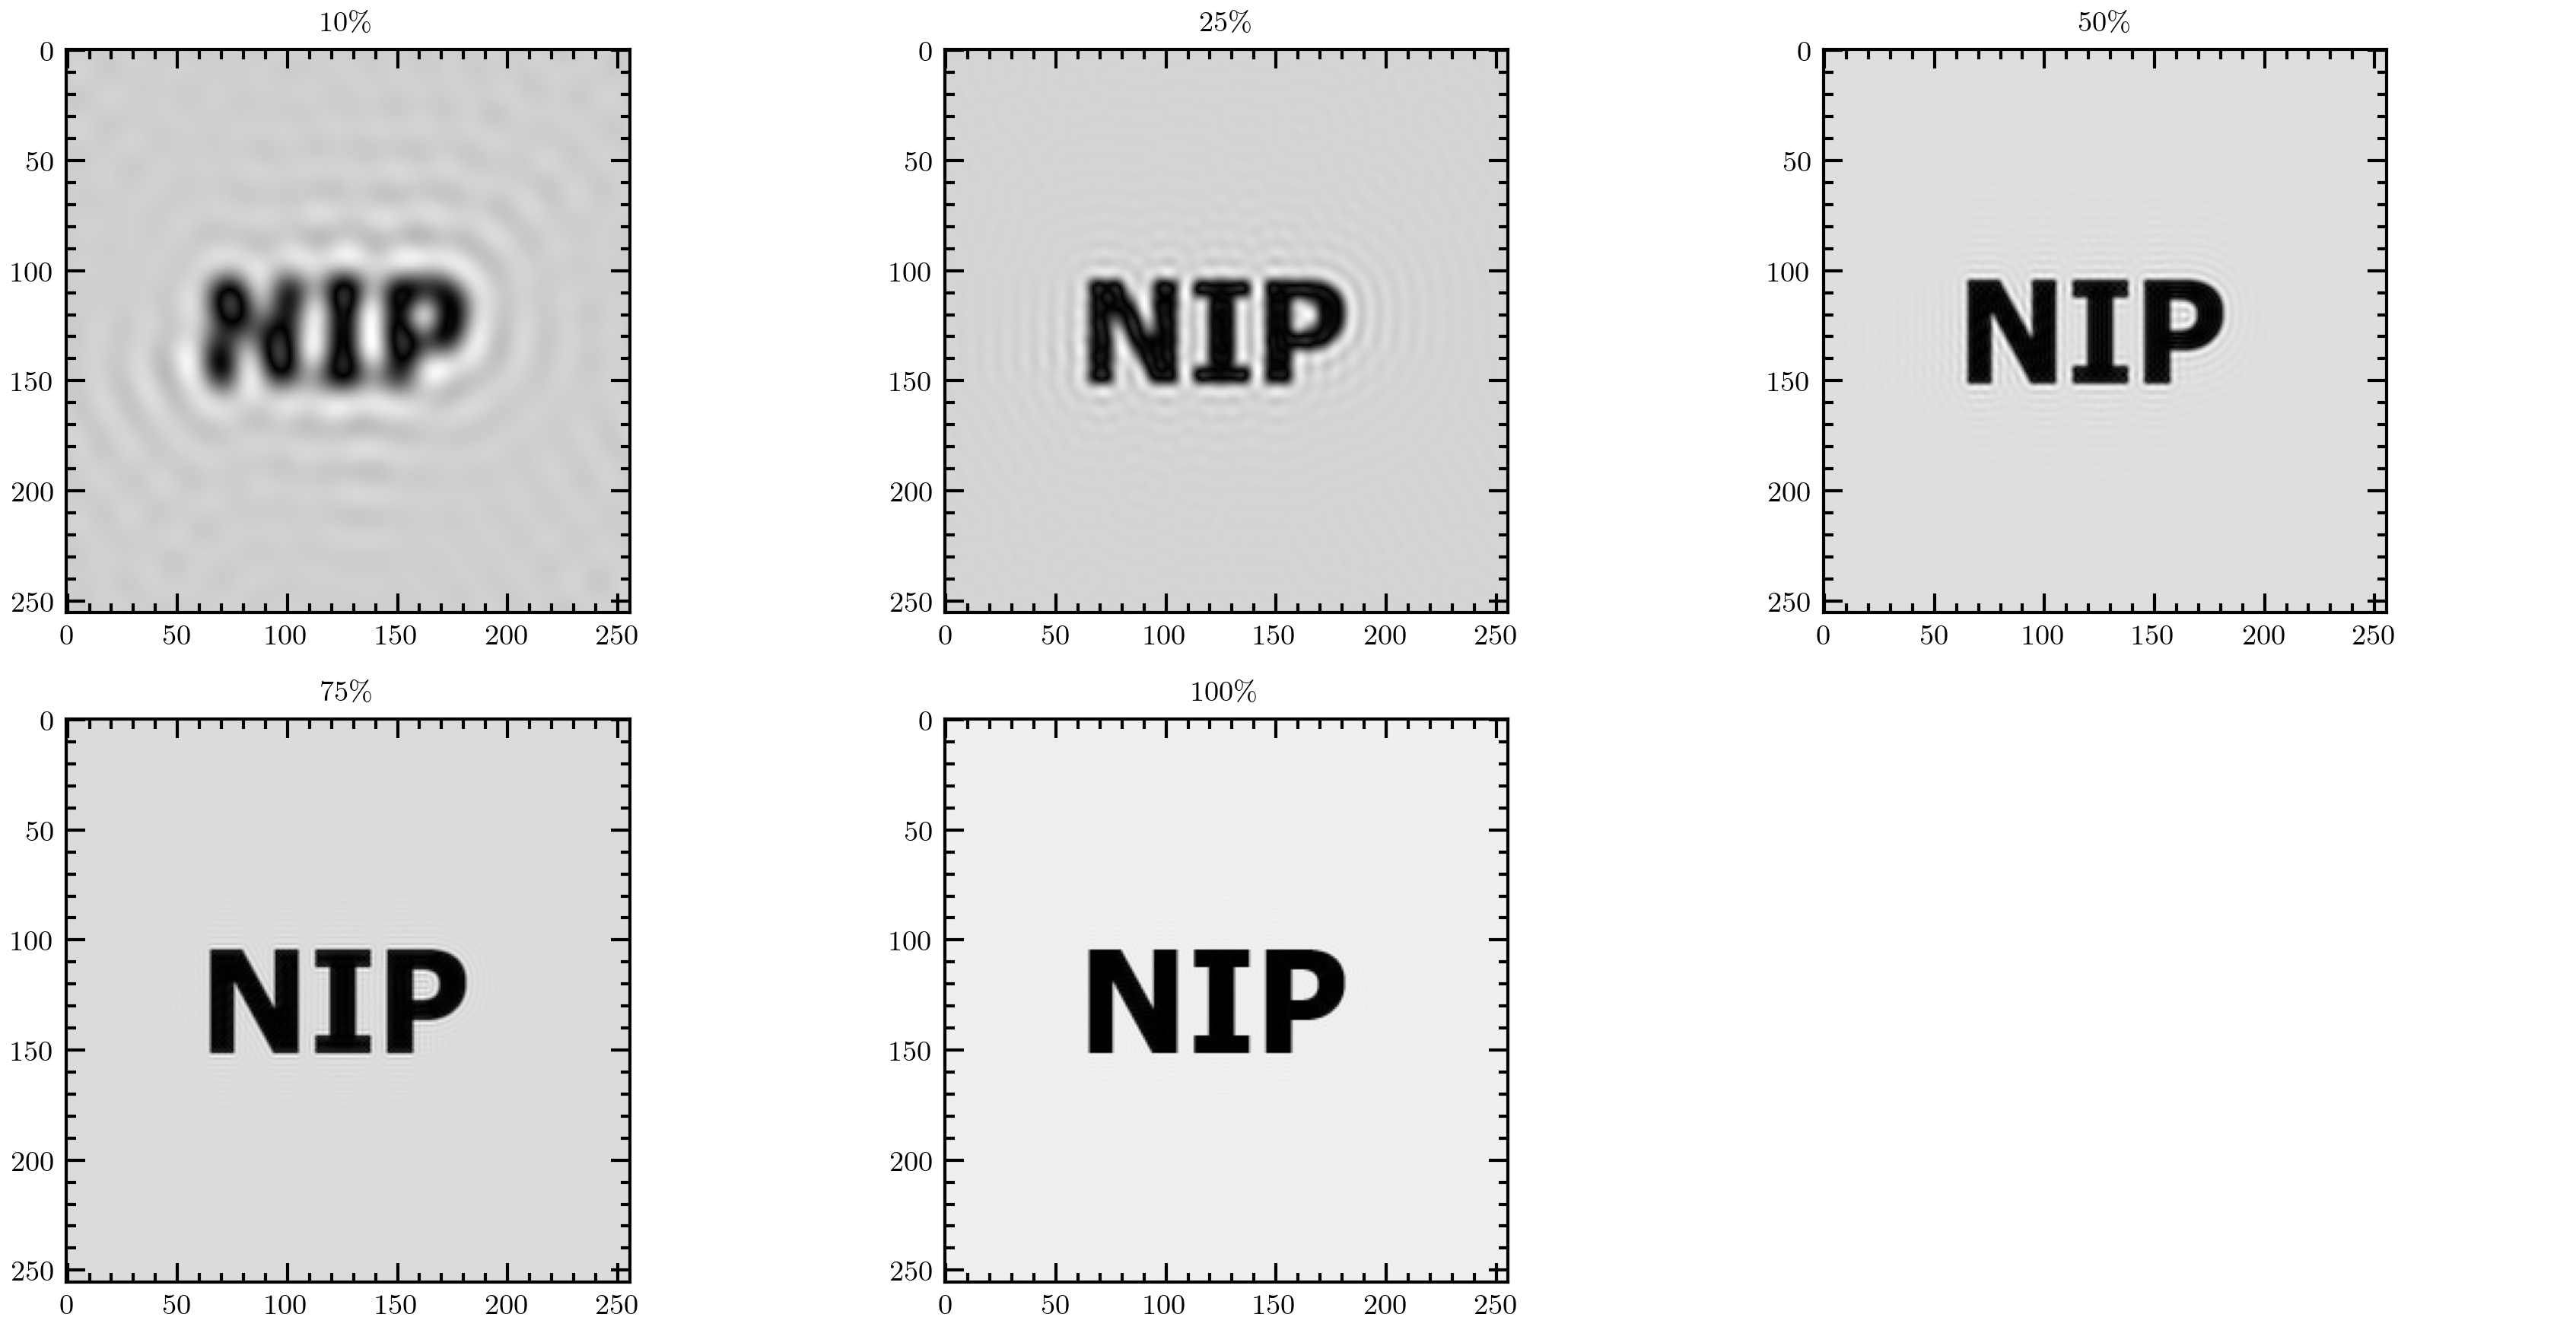

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## load NIP image 
nip = cv2.imread("nip.png", cv2.IMREAD_GRAYSCALE)
nip = nip.astype(float)

## Function to create circular aperture
def circ_aperture(size, diameter_ratio):
    h, w = size
    x = np.linspace(-1, 1, w)
    y = np.linspace(-1, 1, h)
    xv, yv = np.meshgrid(x, y)
    r = diameter_ratio  
    aperture = (xv**2 + yv**2 <= (r)**2).astype(float)
    return aperture

## FFT of NIP (keep complex)
F_nip = np.fft.fft2(nip)

## Aperture sizes (fractions of image width)
ratios = [0.10, 0.25, 0.50, 0.75, 1.00]

plt.figure(figsize=(3,3),dpi=300)
plt.imshow(nip, cmap='gray')
## plt.title("NIP")
plt.axis('off')
plt.show()

## Apertures figure (2x3, leave [1][2] blank)
fig1, axs1 = plt.subplots(2, 3, figsize=(12, 6), dpi=300)

apertures = []
positions = [(0,0), (0,1), (0,2), (1,0), (1,1)]  ## last slot [1][2] left blank

for i, r in enumerate(ratios):
    ap = circ_aperture(nip.shape, r)
    apertures.append(ap)
    
    row, col = positions[i]
    axs1[row][col].imshow(ap, cmap='gray')
    axs1[row][col].set_title(rf"{int(r*100)}\%")
    axs1[row][col].grid()

axs1[1][2].axis('off')

plt.tight_layout()
plt.show()


## Convolution results figure
fig2, axs2 = plt.subplots(2, 3, figsize=(12, 6), dpi=300)

for i, ap in enumerate(apertures):
    ap_shifted = np.fft.fftshift(ap)
    product = F_nip * ap_shifted
    recon = np.fft.ifft2(product)
    recon_abs = np.abs(recon)

    row, col = positions[i]
    axs2[row][col].imshow(recon_abs, cmap='gray')
    axs2[row][col].set_title(rf"{int(ratios[i]*100)}\%")
    axs2[row][col].grid()

axs2[1][2].axis('off')

plt.tight_layout()
plt.show()

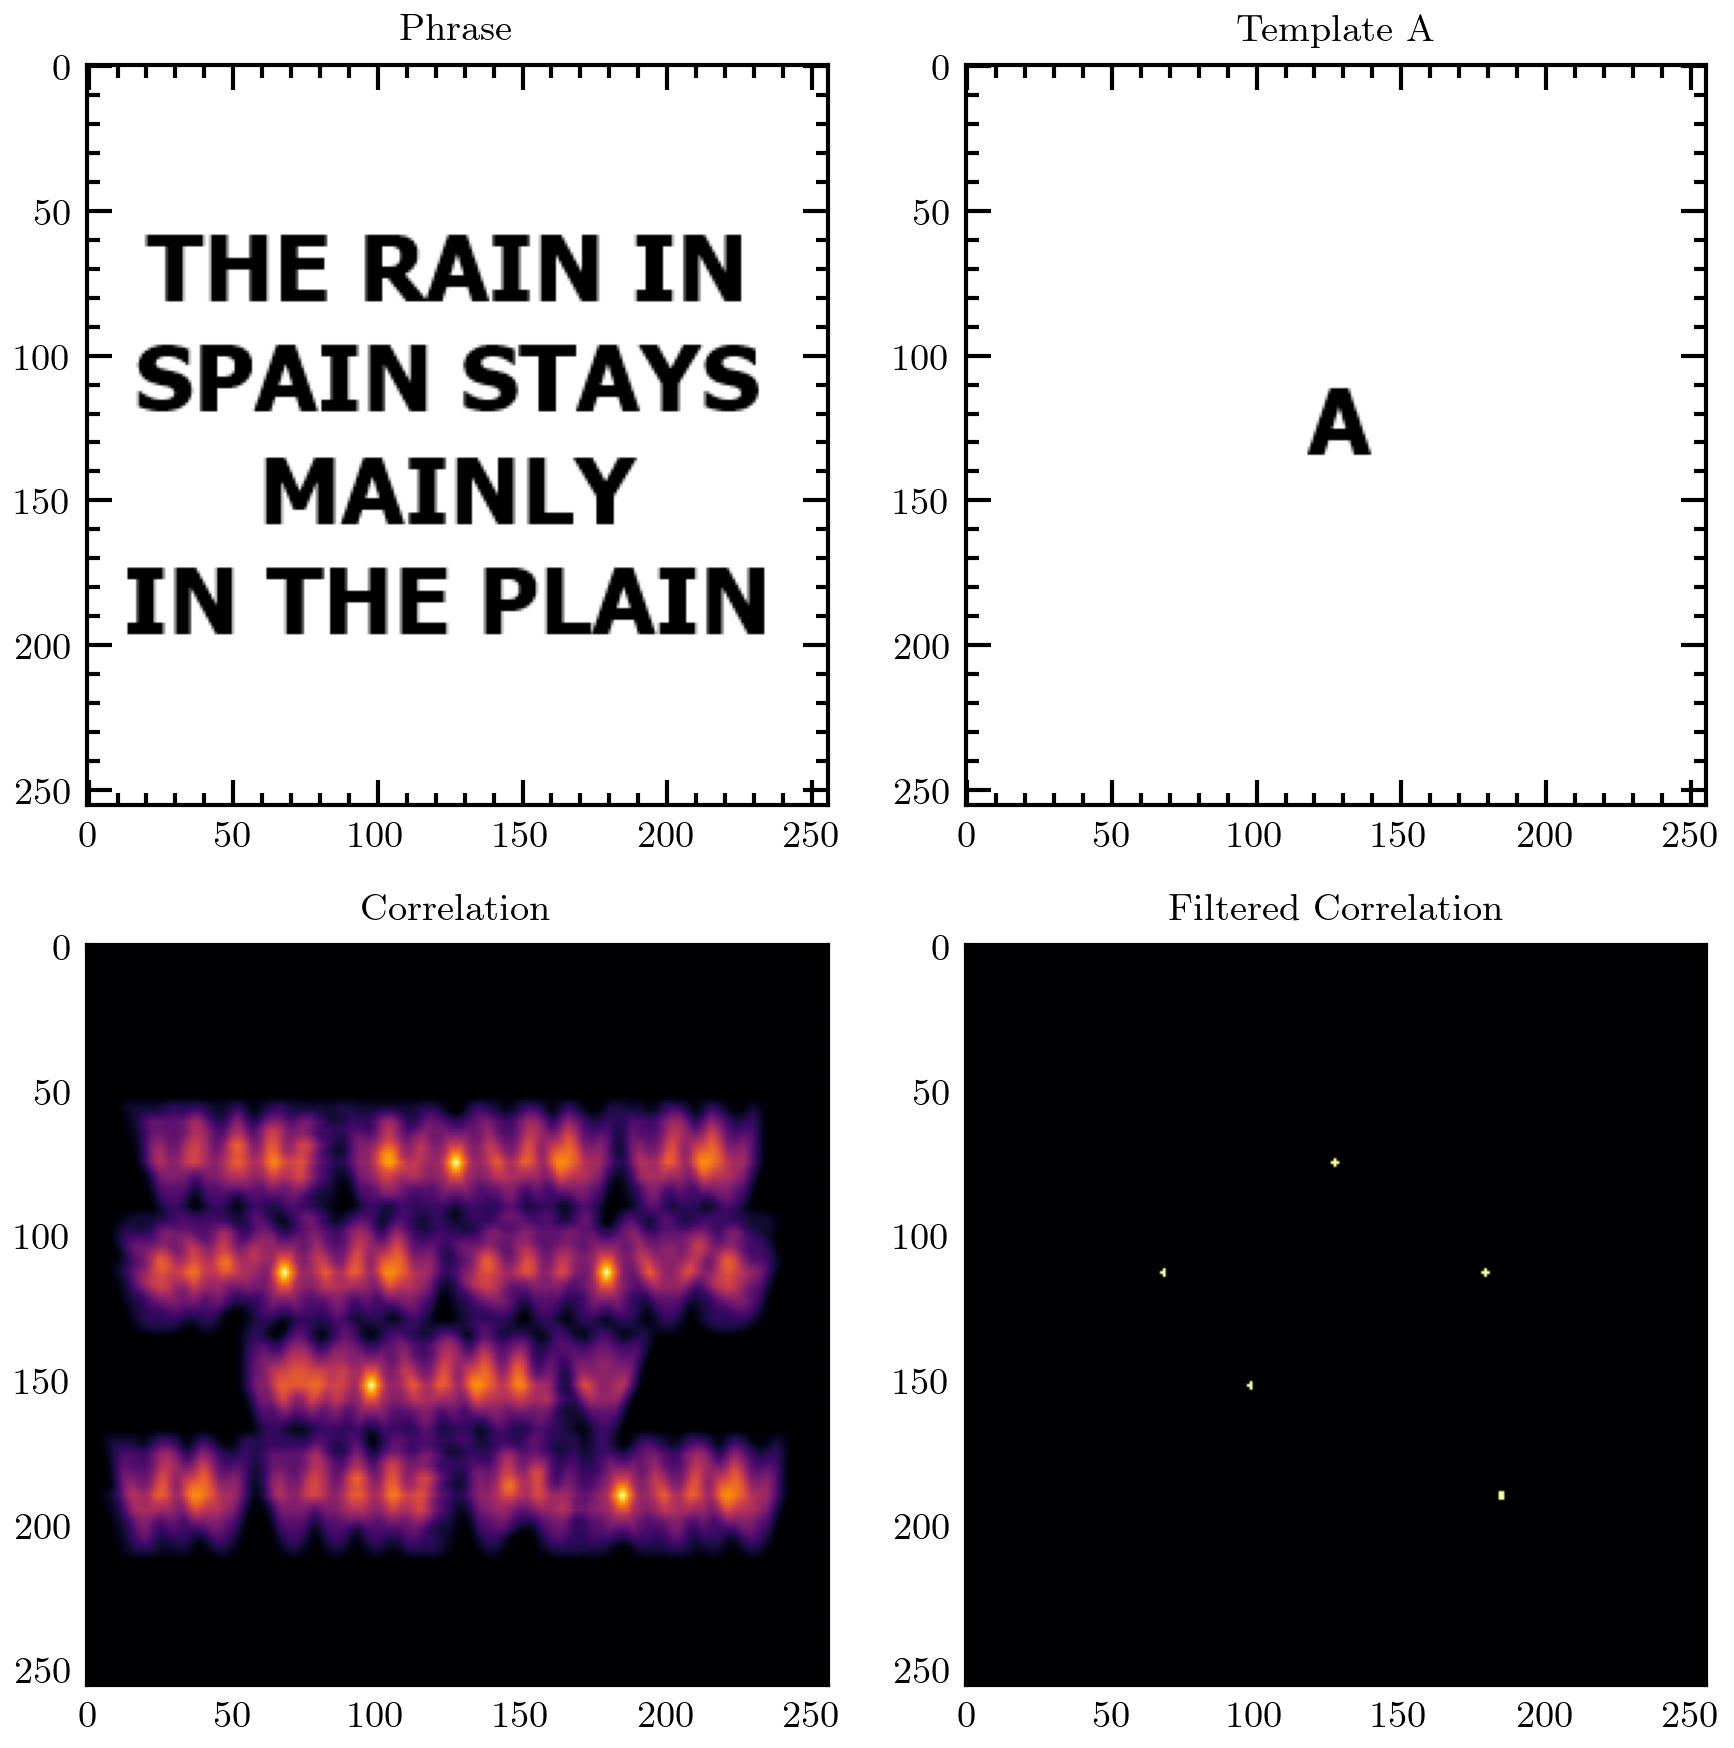

In [81]:
## Load images (grayscale)
rainspain = cv2.imread("rainlol.png", cv2.IMREAD_GRAYSCALE).astype(float)
a_kernel  = cv2.imread("A.png", cv2.IMREAD_GRAYSCALE).astype(float)

## FFT2 of both images
F_img = np.fft.fft2(rainspain)
F_A   = np.fft.fft2(a_kernel)

## Cross-correlation in frequency domain
product = F_img * np.conj(F_A)

## Inverse FFT
corr = np.fft.ifft2(product)
corr_abs = np.abs(corr)

## Center for visualization
corr_shifted = np.fft.fftshift(corr_abs)
corr_shifted = corr_shifted / np.max(corr_shifted)

## Simple threshold filtering
threshold = 0.9 * (np.max(corr_shifted) - np.min(corr_shifted)) + np.min(corr_shifted)

dot_map = np.zeros_like(corr_shifted)
dot_map[corr_shifted >= threshold] = 1
## Figures
fig, axs = plt.subplots(2, 2, figsize=(6, 6), dpi=300)

axs[0][0].imshow(rainspain, cmap='gray')
axs[0][0].set_title("Phrase")
axs[0][0].grid()

axs[0][1].imshow(a_kernel, cmap='gray')
axs[0][1].set_title("Template A")
axs[0][1].grid()

axs[1][0].imshow(corr_shifted, cmap='inferno')
axs[1][0].set_title("Correlation")
axs[1][0].grid()

axs[1][1].imshow(dot_map, cmap='inferno')
axs[1][1].set_title("Filtered Correlation")
axs[1][1].grid()

plt.tight_layout()
plt.show()

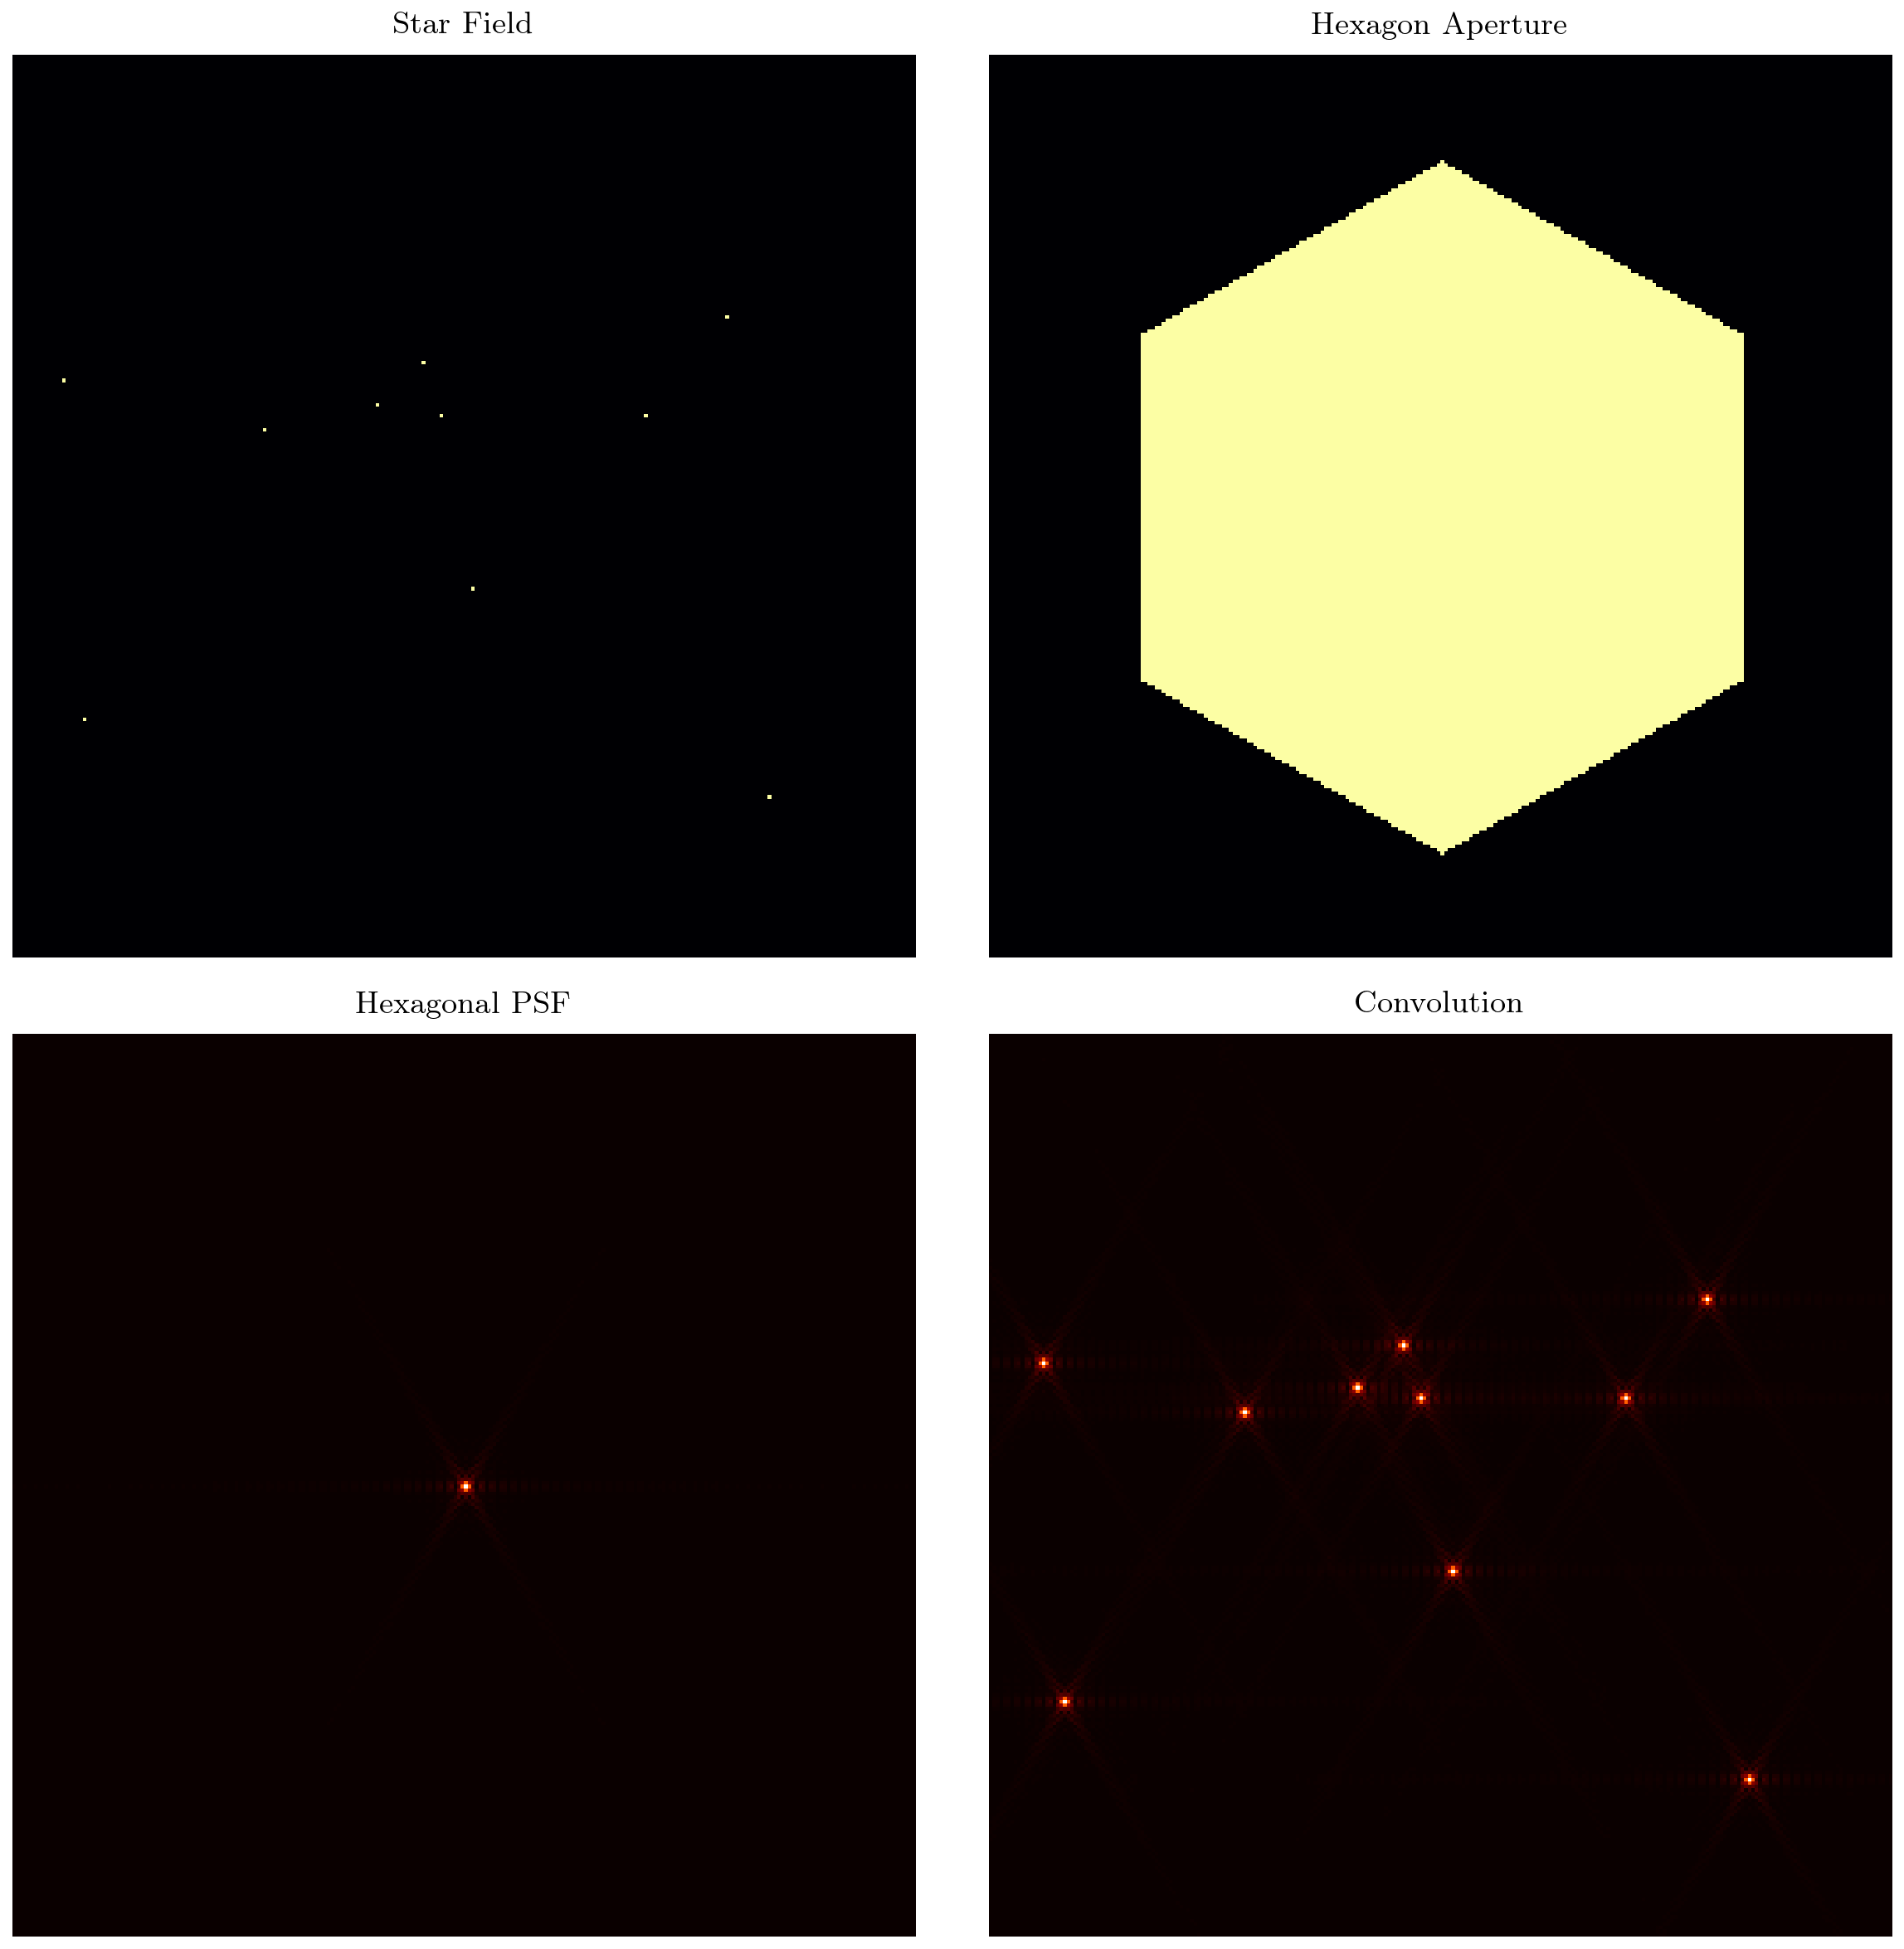

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

## Star field
img = np.zeros((256, 256), dtype=float)

np.random.seed(42)
coords = np.random.randint(0, 256, (10, 2))
for y, x in coords:
    img[y, x] = 1.0

## Aperture (Kernel)
def hexagon_kernel(size=256):
    k = np.zeros((size, size), dtype=float)
    c = size // 2
    R = size // 1.5

    for i in range(size):
        for j in range(size):
            x = j - c
            y = i - c

            if x*x + y*y > R*R:
                continue

            if (abs(x) <= R/2 and
                abs(0.5*x + (np.sqrt(3)/2)*y) <= R/2 and
                abs(0.5*x - (np.sqrt(3)/2)*y) <= R/2):
                k[i, j] = 1.0

    return k / np.sum(k)

kernel = hexagon_kernel()

## Point spred function
kernel_fft = np.fft.fft2(kernel)
kernel_fft = np.abs(np.fft.fftshift(kernel_fft))

## Convolution with psh
conv = convolve2d(img, kernel_fft, mode='same')

## Display
fig, axs = plt.subplots(2, 2, figsize=(8, 8), dpi=300)

axs[0][0].imshow(img, cmap='inferno')
axs[0][0].set_title("Star Field")
axs[0][0].axis('off')

axs[0][1].imshow(kernel, cmap='inferno')
axs[0][1].set_title("Hexagon Aperture")
axs[0][1].axis('off')

axs[1][0].imshow(kernel_fft, cmap='hot')
axs[1][0].set_title("Hexagonal PSF")
axs[1][0].axis('off')

axs[1][1].imshow(conv, cmap='hot')
axs[1][1].set_title("Convolution")
axs[1][1].axis('off')

plt.tight_layout()
plt.show()